# Emotion Recognition with MobileNetV3
### AffectNet + Chinese Facial Expression Dataset — 5 Classes
**Target: >90% Validation Accuracy**

**Classes:** Anger · Fear · Happy · Neutral · Sad  
**Architecture:** MobileNetV3-Large (pretrained ImageNet) with custom classifier head  
**Strategy:** Frozen backbone → Progressive unfreezing → Full fine-tuning with cosine LR

---
## 0. Install & Import Dependencies

In [1]:
import os
import random
import time
import copy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from tqdm.notebook import tqdm

# Reproducibility
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
   GPU: NVIDIA GeForce RTX 4060 Laptop GPU
   VRAM: 8.6 GB


---
## 1. Configuration

In [2]:
# ============================================================
#  CONFIGURATION  — edit paths here
# ============================================================
class Config:
    # ── Dataset ──────────────────────────────────────────────
    DATA_ROOT   = r'E:\LamMinhTri\Tai_Lieu_Hoc_Tap\2026_Semester 1\DAT301m\The_Emotion_Explorers\Mood-and-Attention-Monitoring-in-Online-Classrooms\dataset'          # root folder
    TRAIN_DIR   = r'E:\LamMinhTri\Tai_Lieu_Hoc_Tap\2026_Semester 1\DAT301m\The_Emotion_Explorers\Mood-and-Attention-Monitoring-in-Online-Classrooms\dataset\train'    # subfolders = class names
    TEST_DIR    = r'E:\LamMinhTri\Tai_Lieu_Hoc_Tap\2026_Semester 1\DAT301m\The_Emotion_Explorers\Mood-and-Attention-Monitoring-in-Online-Classrooms\dataset\test'

    CLASSES     = ['anger', 'fear', 'happy', 'neutral', 'sad']
    NUM_CLASSES = 5

    # ── Model ────────────────────────────────────────────────
    MODEL_NAME  = 'mobilenet_v3_large'   # or 'mobilenet_v2'
    IMG_SIZE    = 96
    DROPOUT     = 0.4

    # ── Training phases ──────────────────────────────────────
    # Phase 1: warm-up with frozen backbone
    PHASE1_EPOCHS = 10
    PHASE1_LR     = 3e-3

    # Phase 2: unfreeze last 2 blocks
    PHASE2_EPOCHS = 25
    PHASE2_LR     = 5e-4

    # Phase 3: full fine-tune
    PHASE3_EPOCHS = 200
    PHASE3_LR     = 1e-4

    # ── Optimiser ────────────────────────────────────────────
    WEIGHT_DECAY  = 1e-4
    BATCH_SIZE    = 32
    NUM_WORKERS   = 4

    # ── Misc ─────────────────────────────────────────────────
    SAVE_DIR      = './checkpoints'
    BEST_CKPT     = './checkpoints/mobilenet_v3_large.pth'
    USE_AMP       = True      # mixed-precision (set False if no CUDA)
    EARLY_STOP    = 20         # patience epochs

cfg = Config()
os.makedirs(cfg.SAVE_DIR, exist_ok=True)
print('Config loaded')

Config loaded


---
## 2. Dataset Exploration

         Train  Test
anger     1325  1253
fear      1325  1253
happy     1325  1253
neutral   1325  1253
sad       1325  1253
TOTAL     6625  6265


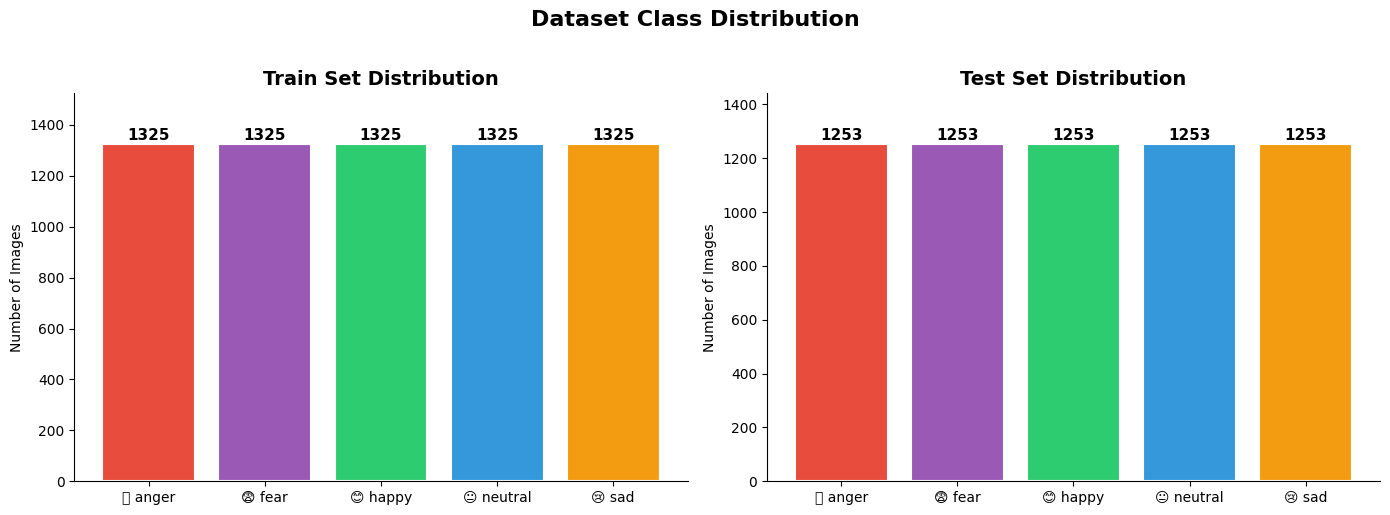

In [3]:
def count_dataset(root):
    counts = {}
    for cls in sorted(os.listdir(root)):
        cls_path = os.path.join(root, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_dataset(cfg.TRAIN_DIR)
test_counts  = count_dataset(cfg.TEST_DIR)

df_dist = pd.DataFrame({'Train': train_counts, 'Test': test_counts})
df_dist.loc['TOTAL'] = df_dist.sum()
print(df_dist.to_string())

# Visualise distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
emoji = {'anger':'😤','fear':'😨','happy':'😊','neutral':'😐','sad':'😢'}
colors = ['#E74C3C','#9B59B6','#2ECC71','#3498DB','#F39C12']

for ax, (split, counts) in zip(axes, [('Train', train_counts), ('Test', test_counts)]):
    labels = [f"{emoji.get(k,'')} {k}" for k in counts]
    bars = ax.bar(labels, counts.values(), color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(f'{split} Set Distribution', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.set_ylim(0, max(counts.values()) * 1.15)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Dataset Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

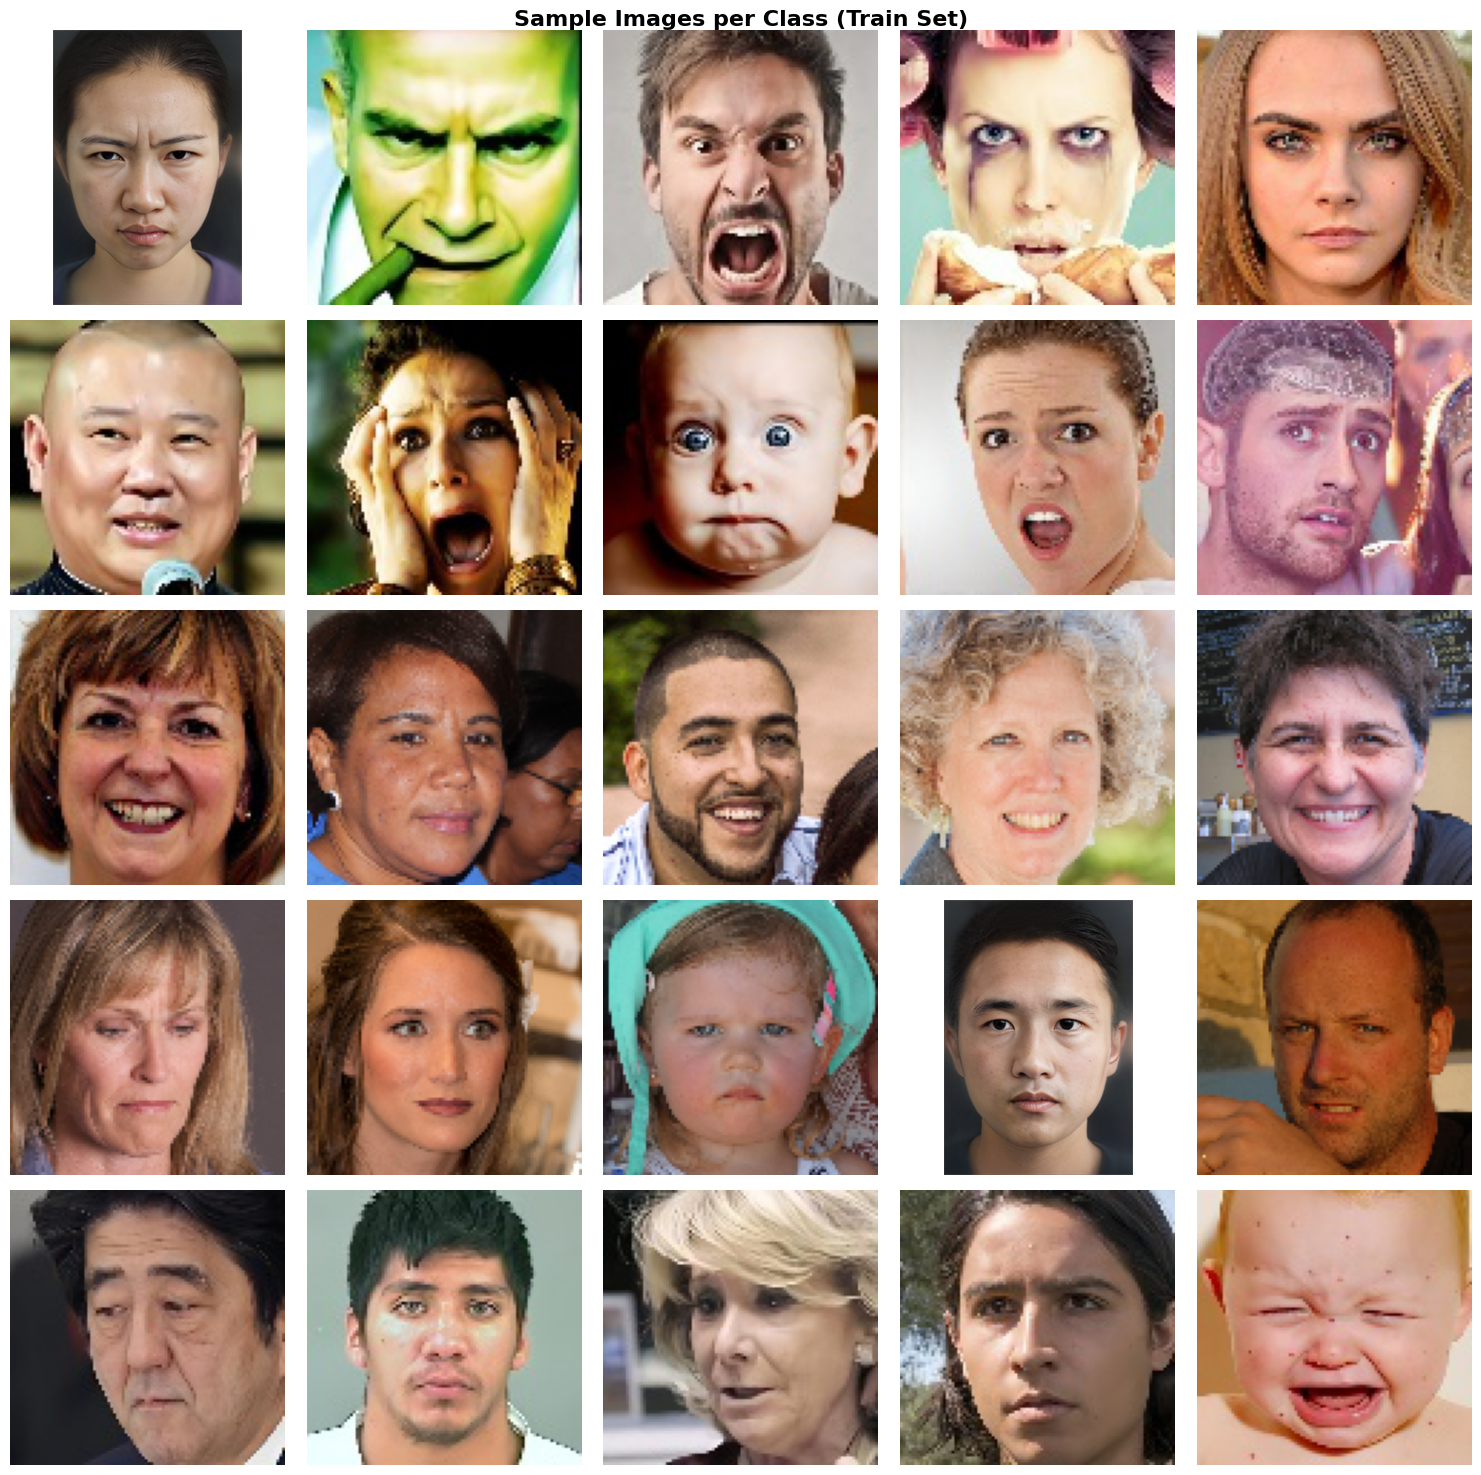

In [4]:
# Sample grid: show 5 images per class from Train
fig, axes = plt.subplots(cfg.NUM_CLASSES, 5, figsize=(15, cfg.NUM_CLASSES * 3))
for row, cls in enumerate(cfg.CLASSES):
    cls_dir = os.path.join(cfg.TRAIN_DIR, cls)
    imgs = random.sample(os.listdir(cls_dir), min(5, len(os.listdir(cls_dir))))
    for col, fname in enumerate(imgs):
        img = Image.open(os.path.join(cls_dir, fname)).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(f"{emoji.get(cls,'')} {cls}",
                                       fontsize=13, fontweight='bold',
                                       rotation=0, ha='right', va='center')
            axes[row, col].yaxis.set_visible(True)

plt.suptitle('Sample Images per Class (Train Set)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Data Augmentation & Transforms

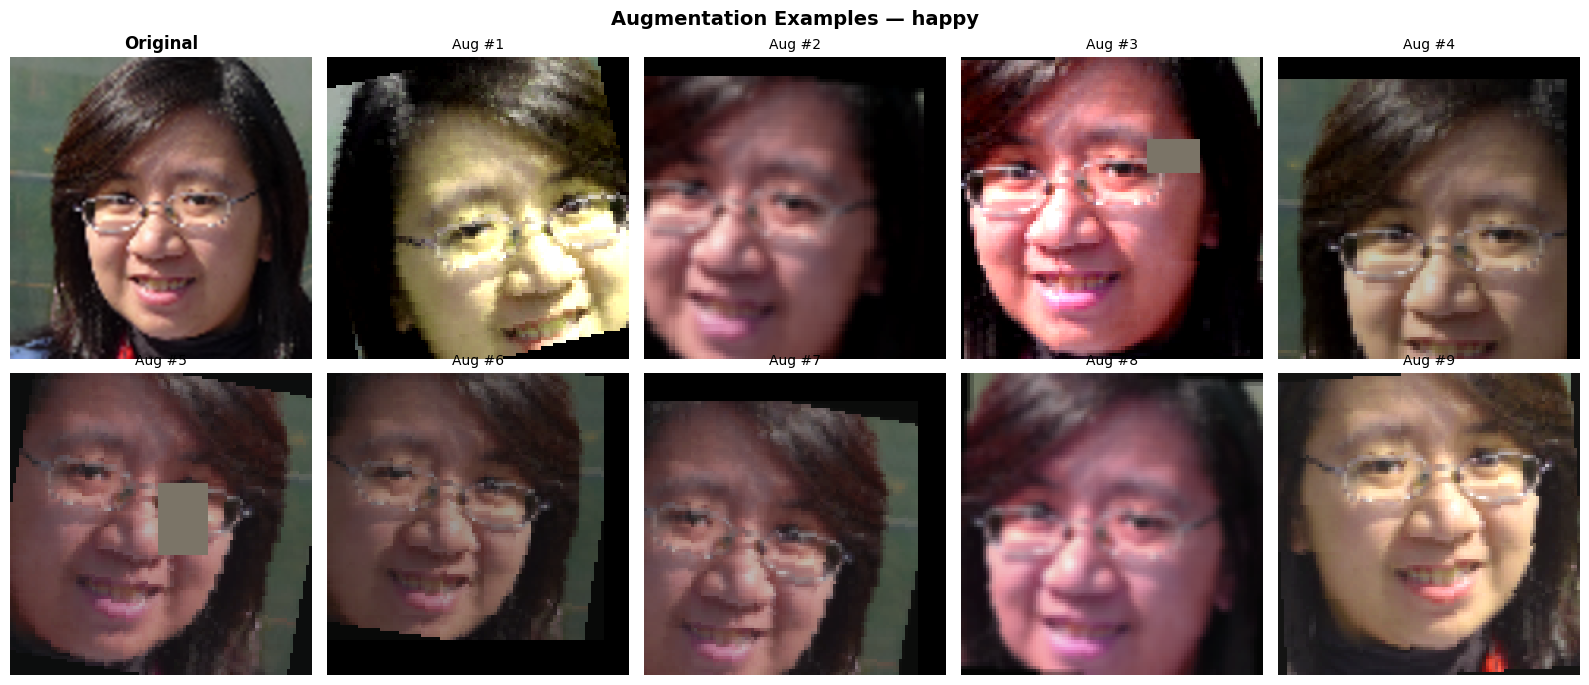

In [5]:
# ImageNet normalisation stats
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE + 32, cfg.IMG_SIZE + 32)),
    transforms.RandomCrop(cfg.IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.RandomApply([transforms.RandomAffine(
        degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1))], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

val_transforms = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Visualise augmentations on a sample image
sample_cls = 'happy'
sample_dir = os.path.join(cfg.TRAIN_DIR, sample_cls)
sample_path = os.path.join(sample_dir, os.listdir(sample_dir)[0])
orig_img = Image.open(sample_path).convert('RGB')

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes[0, 0].imshow(orig_img.resize((224, 224)))
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

unnorm = transforms.Compose([
    transforms.Normalize(mean=[0,0,0], std=[1/s for s in STD]),
    transforms.Normalize(mean=[-m for m in MEAN], std=[1,1,1]),
])

for i, ax in enumerate(axes.flat[1:], 1):
    aug = train_transforms(orig_img)
    img_show = unnorm(aug).permute(1,2,0).numpy().clip(0,1)
    ax.imshow(img_show)
    ax.set_title(f'Aug #{i}', fontsize=10)
    ax.axis('off')

plt.suptitle(f'Augmentation Examples — {sample_cls}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. DataLoaders

In [6]:
train_dataset = ImageFolder(cfg.TRAIN_DIR, transform=train_transforms)
test_dataset  = ImageFolder(cfg.TEST_DIR,  transform=val_transforms)

print(f'Train: {len(train_dataset):,} images | Test: {len(test_dataset):,} images')
print(f'Class → index mapping: {train_dataset.class_to_idx}')

# Weighted sampler (helps even on balanced sets — stabilises early training)
targets = torch.tensor(train_dataset.targets)
class_counts = torch.bincount(targets)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE,
                          sampler=sampler, num_workers=cfg.NUM_WORKERS,
                          pin_memory=True, persistent_workers=(cfg.NUM_WORKERS > 0),
                          drop_last=True)

test_loader  = DataLoader(test_dataset,  batch_size=cfg.BATCH_SIZE,
                          shuffle=False,  num_workers=cfg.NUM_WORKERS,
                          pin_memory=True, persistent_workers=(cfg.NUM_WORKERS > 0))

print(f'\nBatches — Train: {len(train_loader)} | Test: {len(test_loader)}')

Train: 6,625 images | Test: 6,265 images
Class → index mapping: {'anger': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4}

Batches — Train: 207 | Test: 196


---
## 5. Model Architecture

In [7]:
def build_mobilenet(num_classes=5, dropout=0.4, pretrained=True):
    """MobileNetV3-Large with custom classifier head."""
    weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2 if pretrained else None
    model = models.mobilenet_v3_large(weights=weights)

    # Replace classifier: adaptive pool → BN → Dropout → Linear → GELU → BN → Dropout → Linear
    in_features = model.classifier[0].in_features  # 960
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.Hardswish(),
        nn.Dropout(p=dropout),
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.Hardswish(),
        nn.Dropout(p=dropout / 2),
        nn.Linear(256, num_classes),
    )

    # Xavier init for new layers
    for m in model.classifier.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    return model


def freeze_backbone(model):
    """Freeze all layers except the classifier."""
    for name, param in model.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = False


def unfreeze_last_n_blocks(model, n=2):
    """Unfreeze the last n inverted-residual blocks + classifier."""
    # MobileNetV3 features are in model.features (list of blocks)
    total_blocks = len(model.features)
    unfreeze_from = total_blocks - n
    for i, block in enumerate(model.features):
        requires = (i >= unfreeze_from)
        for p in block.parameters():
            p.requires_grad = requires
    for p in model.classifier.parameters():
        p.requires_grad = True


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


model = build_mobilenet(cfg.NUM_CLASSES, cfg.DROPOUT)
model = model.to(DEVICE)

total, trainable = count_params(model)
print(f'Total params   : {total:,}')
print(f'Trainable params: {trainable:,}')
print(model)

Total params   : 3,598,133
Trainable params: 3,598,133
MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0

---
## 6. Training Utilities

In [8]:
# ── Label Smoothing Loss ─────────────────────────────────────
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.1, num_classes=5):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes

    def forward(self, pred, target):
        log_prob = F.log_softmax(pred, dim=-1)
        smooth_target = torch.full_like(log_prob, self.smoothing / (self.num_classes - 1))
        smooth_target.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        return -(smooth_target * log_prob).sum(dim=-1).mean()


# ── Mixup augmentation ───────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ── Training / Validation loops ──────────────────────────────
def train_epoch(model, loader, criterion, optimiser, scaler, use_mixup=True):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        if use_mixup:
            imgs, labels_a, labels_b, lam = mixup_data(imgs, labels)

        optimiser.zero_grad(set_to_none=True)
        with autocast(enabled=cfg.USE_AMP and DEVICE.type == 'cuda'):
            outputs = model(imgs)
            if use_mixup:
                loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
            else:
                loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimiser)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimiser)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        # For mixup accuracy, compare against dominant label
        ref = labels_a if use_mixup else labels
        correct += predicted.eq(ref).sum().item()
        total   += imgs.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in tqdm(loader, desc='  Val  ', leave=False):
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        with autocast(enabled=cfg.USE_AMP and DEVICE.type == 'cuda'):
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        running_loss += loss.item() * imgs.size(0)
        correct += predicted.eq(labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return (running_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


print('✅ Training utilities ready')

✅ Training utilities ready


---
## 7. Live Training Visualisation Setup

In [9]:
%matplotlib inline
from IPython.display import clear_output

history = defaultdict(list)  # stores metrics across all phases

def plot_training_progress(history, phase_boundaries=None):
    """Live-updating 2x2 dashboard."""
    clear_output(wait=True)
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    epochs = range(1, len(history['train_loss']) + 1)

    # ── 1. Loss ──────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, history['train_loss'], 'b-o', ms=4, label='Train')
    ax1.plot(epochs, history['val_loss'],   'r-s', ms=4, label='Val')
    ax1.set_title('Loss', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    # ── 2. Accuracy ──────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    train_acc = [a * 100 for a in history['train_acc']]
    val_acc   = [a * 100 for a in history['val_acc']]
    ax2.plot(epochs, train_acc, 'b-o', ms=4, label='Train')
    ax2.plot(epochs, val_acc,   'r-s', ms=4, label='Val')
    ax2.axhline(90, color='green', linestyle='--', linewidth=1.5, label='90% target')
    best_val = max(val_acc) if val_acc else 0
    ax2.set_title(f'Accuracy  (Best Val: {best_val:.2f}%)', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_ylim(0, 105)
    ax2.legend(); ax2.grid(alpha=0.3)

    # ── 3. LR curve ──────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(epochs, history['lr'], 'g-', linewidth=2)
    ax3.set_title('Learning Rate Schedule', fontweight='bold')
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR')
    ax3.set_yscale('log'); ax3.grid(alpha=0.3)

    # ── 4. Train/Val gap ─────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    gap = [t - v for t, v in zip(train_acc, val_acc)]
    ax4.bar(epochs, gap, color=['#E74C3C' if g > 5 else '#2ECC71' for g in gap], edgecolor='white')
    ax4.axhline(0, color='black', linewidth=0.8)
    ax4.set_title('Train−Val Accuracy Gap (overfit indicator)', fontweight='bold')
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('Gap (%)')
    ax4.grid(alpha=0.3, axis='y')

    # Phase boundary lines
    if phase_boundaries:
        for pb in phase_boundaries:
            for ax in [ax1, ax2, ax3, ax4]:
                ax.axvline(pb, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)

    plt.suptitle('🏋️ Training Dashboard', fontsize=18, fontweight='bold', y=1.01)
    plt.show()

print('✅ Visualisation utilities ready')

✅ Visualisation utilities ready


---
## 8. Three-Phase Training

In [10]:
criterion = LabelSmoothingCE(smoothing=0.1, num_classes=cfg.NUM_CLASSES)
scaler    = GradScaler(enabled=cfg.USE_AMP and DEVICE.type == 'cuda')

best_val_acc    = 0.0
patience_counter = 0
phase_boundaries = []
global_epoch     = 0

def run_phase(model, phase_num, epochs, lr, freeze_fn=None, use_mixup=True):
    global best_val_acc, patience_counter, global_epoch

    if freeze_fn:
        freeze_fn(model)
    total, trainable = count_params(model)
    print(f"\n{'='*60}")
    print(f'  PHASE {phase_num} — LR={lr} | Trainable params: {trainable:,}/{total:,}')
    print(f"{'='*60}")

    optimiser = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=cfg.WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs, eta_min=lr/20)

    for ep in range(1, epochs + 1):
        global_epoch += 1
        t0 = time.time()

        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimiser, scaler, use_mixup)
        vl_loss, vl_acc, preds, labels_gt, probs = eval_epoch(model, test_loader, criterion)

        scheduler.step()
        cur_lr = scheduler.get_last_lr()[0]

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['lr'].append(cur_lr)

        elapsed = time.time() - t0
        print(f'  Ep {ep:02d}/{epochs} | '
              f'T-Loss:{tr_loss:.4f} T-Acc:{tr_acc*100:.2f}% | '
              f'V-Loss:{vl_loss:.4f} V-Acc:{vl_acc*100:.2f}% | '
              f'LR:{cur_lr:.2e} | {elapsed:.1f}s')

        # Save best
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            patience_counter = 0
            torch.save({'epoch': global_epoch,
                        'model_state': model.state_dict(),
                        'val_acc': best_val_acc,
                        'preds': preds, 'labels': labels_gt, 'probs': probs},
                       cfg.BEST_CKPT)
            print(f'  ✅ New best: {best_val_acc*100:.2f}% — checkpoint saved')
        else:
            patience_counter += 1

        # Live plot
        plot_training_progress(history, phase_boundaries)

        # Early stopping (only in phase 3)
        if phase_num == 3 and patience_counter >= cfg.EARLY_STOP:
            print(f'⏹️  Early stopping — no improvement for {cfg.EARLY_STOP} epochs')
            break

    phase_boundaries.append(global_epoch)
    return preds, labels_gt, probs

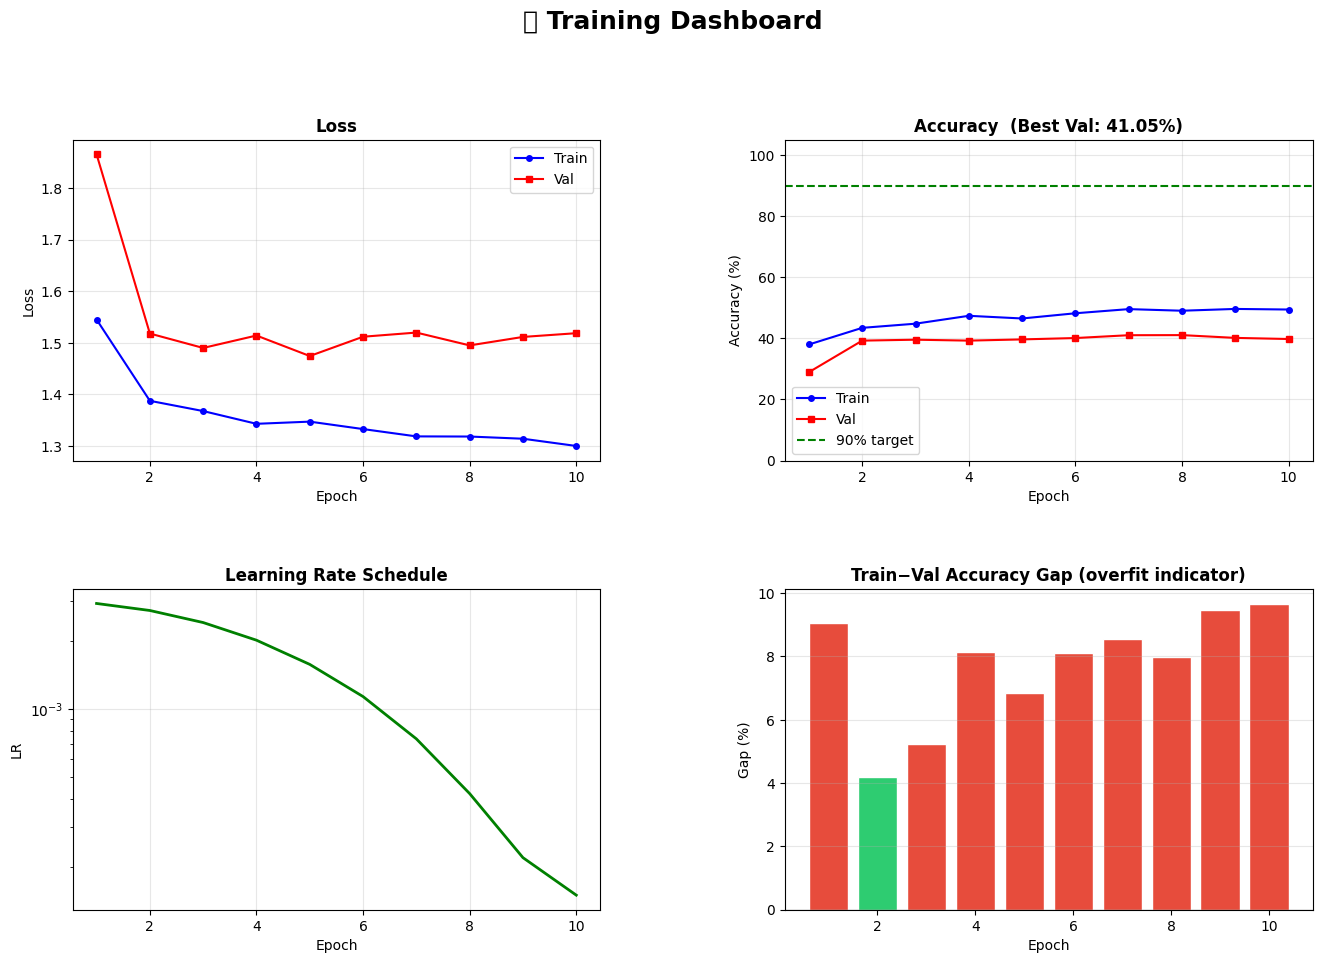

(array([2, 3, 0, ..., 3, 3, 3]),
 array([0, 0, 0, ..., 4, 4, 4]),
 array([[0.06232, 0.0742 , 0.451  , 0.3708 , 0.04166],
        [0.04932, 0.02945, 0.3652 , 0.507  , 0.04922],
        [0.2568 , 0.2202 , 0.2219 , 0.0987 , 0.2024 ],
        ...,
        [0.0833 , 0.10785, 0.1345 , 0.449  , 0.2253 ],
        [0.1968 , 0.0658 , 0.04248, 0.459  , 0.2361 ],
        [0.09955, 0.2417 , 0.1318 , 0.2854 , 0.2416 ]], dtype=float16))

In [11]:
# ── PHASE 1: Frozen backbone — warm up classifier ────────────
run_phase(model, phase_num=1, epochs=cfg.PHASE1_EPOCHS, lr=cfg.PHASE1_LR,
          freeze_fn=freeze_backbone, use_mixup=False)

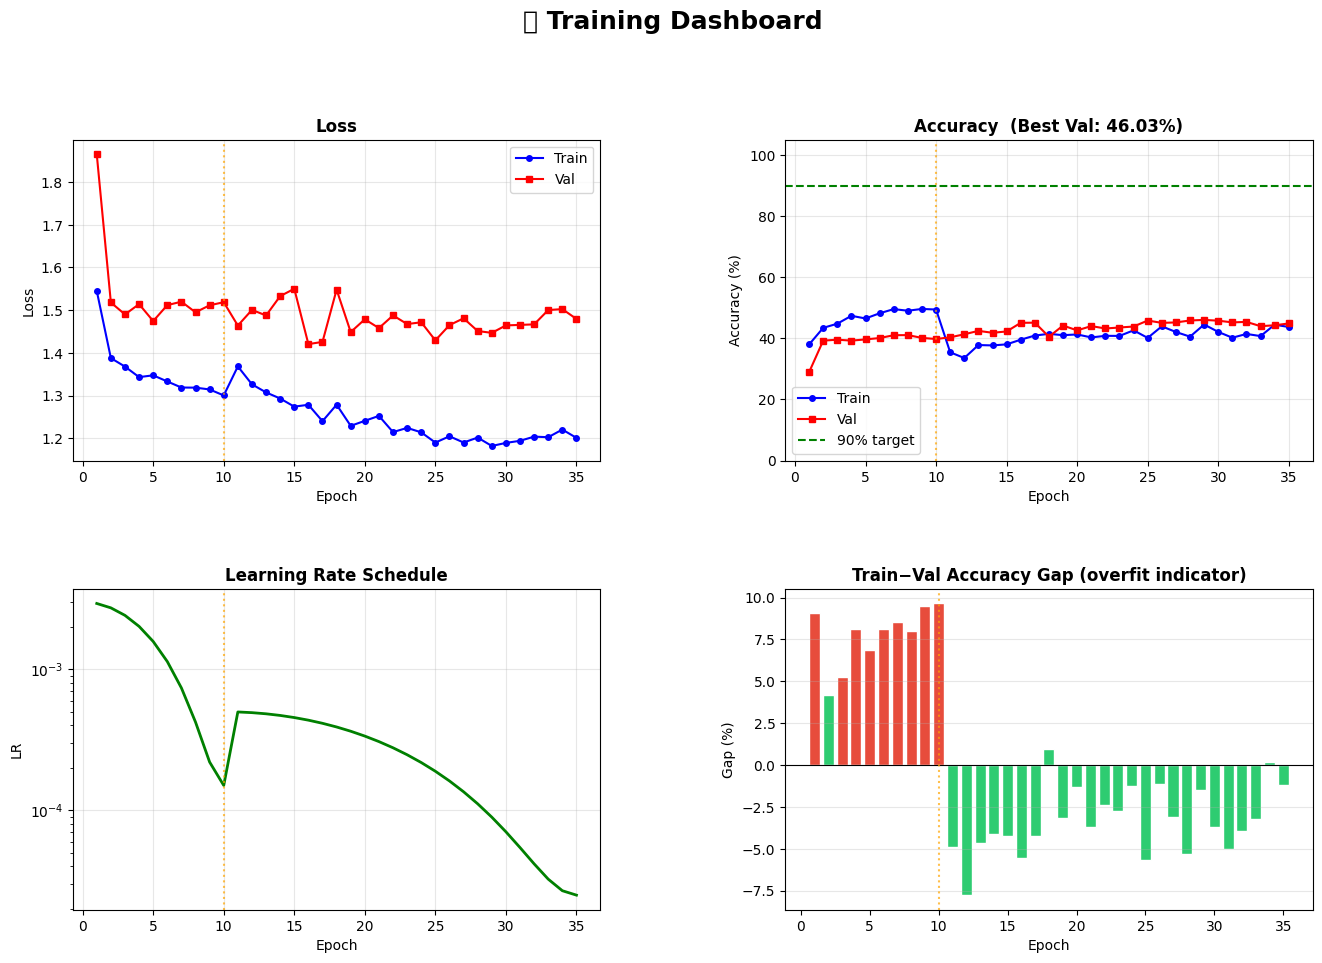

(array([2, 3, 0, ..., 3, 3, 3]),
 array([0, 0, 0, ..., 4, 4, 4]),
 array([[0.1235 , 0.0342 , 0.4587 , 0.3396 , 0.04395],
        [0.204  , 0.0542 , 0.1692 , 0.5054 , 0.06744],
        [0.476  , 0.209  , 0.1315 , 0.03195, 0.1514 ],
        ...,
        [0.02945, 0.049  , 0.043  , 0.7803 , 0.09814],
        [0.10614, 0.02942, 0.0761 , 0.5425 , 0.2461 ],
        [0.0574 , 0.06854, 0.1715 , 0.5923 , 0.11005]], dtype=float16))

In [12]:
# ── PHASE 2: Unfreeze last 2 blocks ──────────────────────────
run_phase(model, phase_num=2, epochs=cfg.PHASE2_EPOCHS, lr=cfg.PHASE2_LR,
          freeze_fn=lambda m: unfreeze_last_n_blocks(m, n=2), use_mixup=True)

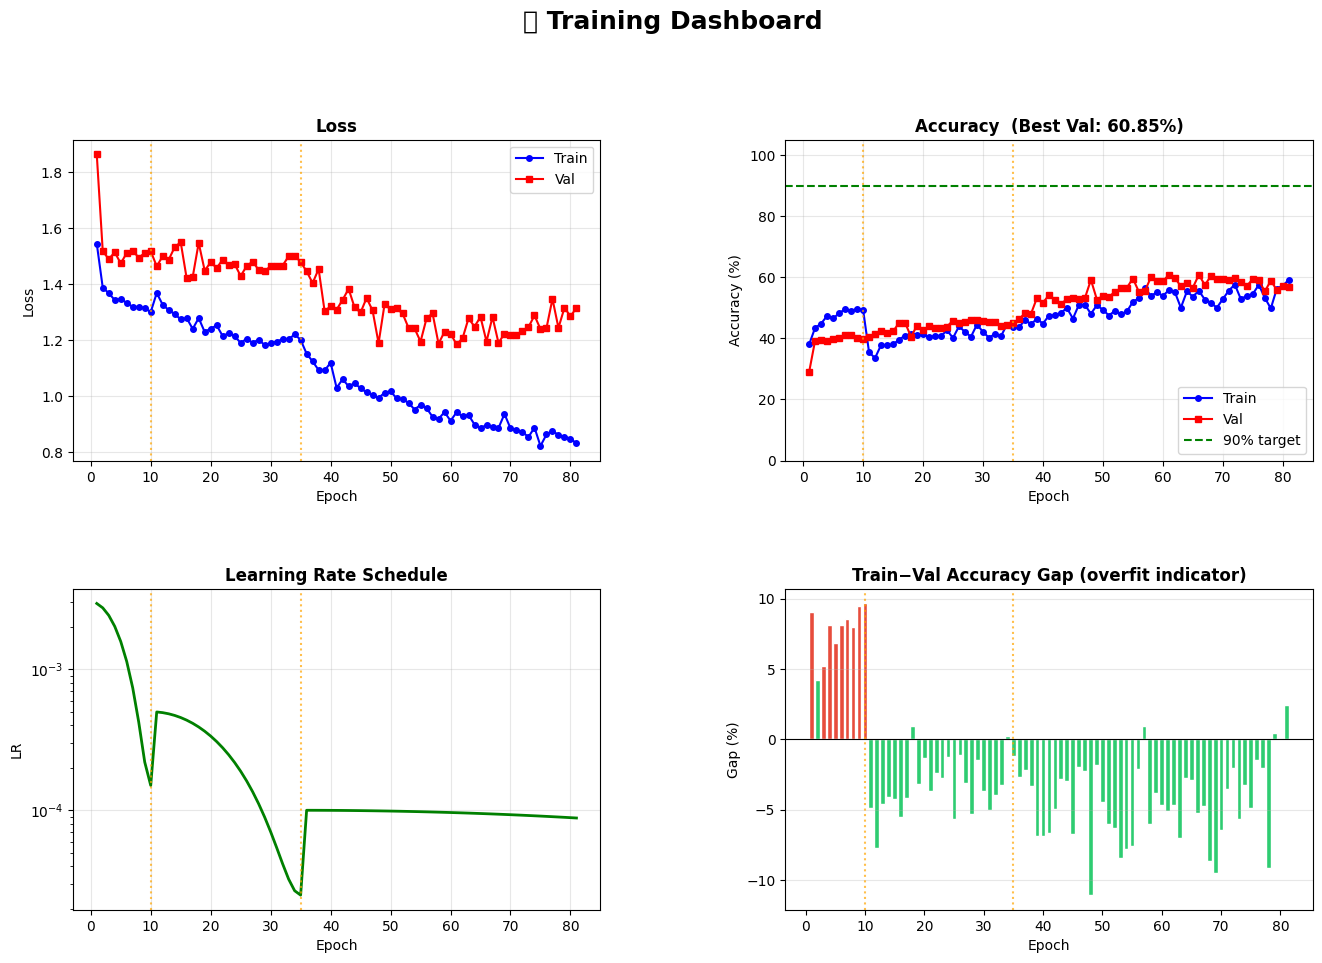

⏹️  Early stopping — no improvement for 20 epochs

🏆 Training complete! Best Val Accuracy: 60.85%


In [13]:
# ── PHASE 3: Full fine-tune ───────────────────────────────────
run_phase(model, phase_num=3, epochs=cfg.PHASE3_EPOCHS, lr=cfg.PHASE3_LR,
          freeze_fn=unfreeze_all, use_mixup=True)

print(f'\n🏆 Training complete! Best Val Accuracy: {best_val_acc*100:.2f}%')

---
## 9. Final Evaluation on Best Checkpoint

In [14]:
# Load best model
ckpt = torch.load(cfg.BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'✅ Loaded best checkpoint from epoch {ckpt["epoch"]} — Val Acc: {ckpt["val_acc"]*100:.2f}%')

# Re-evaluate with TTA (Test-Time Augmentation)
tta_transforms = [
    val_transforms,
    transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]),
    transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE + 20, cfg.IMG_SIZE + 20)),
        transforms.CenterCrop(cfg.IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]),
]

@torch.no_grad()
def evaluate_with_tta(model, data_dir, transforms_list):
    model.eval()
    all_probs, all_labels = [], []

    for tfm in transforms_list:
        ds = ImageFolder(data_dir, transform=tfm)
        dl = DataLoader(ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                        num_workers=cfg.NUM_WORKERS)
        probs_aug, labels_aug = [], []
        for imgs, labels in tqdm(dl, desc=f'  TTA', leave=False):
            imgs = imgs.to(DEVICE, non_blocking=True)
            with autocast(enabled=cfg.USE_AMP and DEVICE.type == 'cuda'):
                out = model(imgs)
            probs_aug.extend(F.softmax(out, dim=1).cpu().numpy())
            labels_aug.extend(labels.numpy())
        all_probs.append(np.array(probs_aug))
        all_labels = labels_aug  # same across TTA passes

    avg_probs  = np.mean(all_probs, axis=0)
    final_preds = avg_probs.argmax(axis=1)
    accuracy    = (final_preds == np.array(all_labels)).mean()
    return final_preds, np.array(all_labels), avg_probs, accuracy

tta_preds, tta_labels, tta_probs, tta_acc = evaluate_with_tta(model, cfg.TEST_DIR, tta_transforms)
print(f'\n🎯 TTA Accuracy: {tta_acc*100:.2f}%')

✅ Loaded best checkpoint from epoch 61 — Val Acc: 60.85%


  TTA:   0%|          | 0/196 [00:00<?, ?it/s]

  TTA:   0%|          | 0/196 [00:00<?, ?it/s]

  TTA:   0%|          | 0/196 [00:00<?, ?it/s]


🎯 TTA Accuracy: 67.85%


---
## 10. Results Visualisation

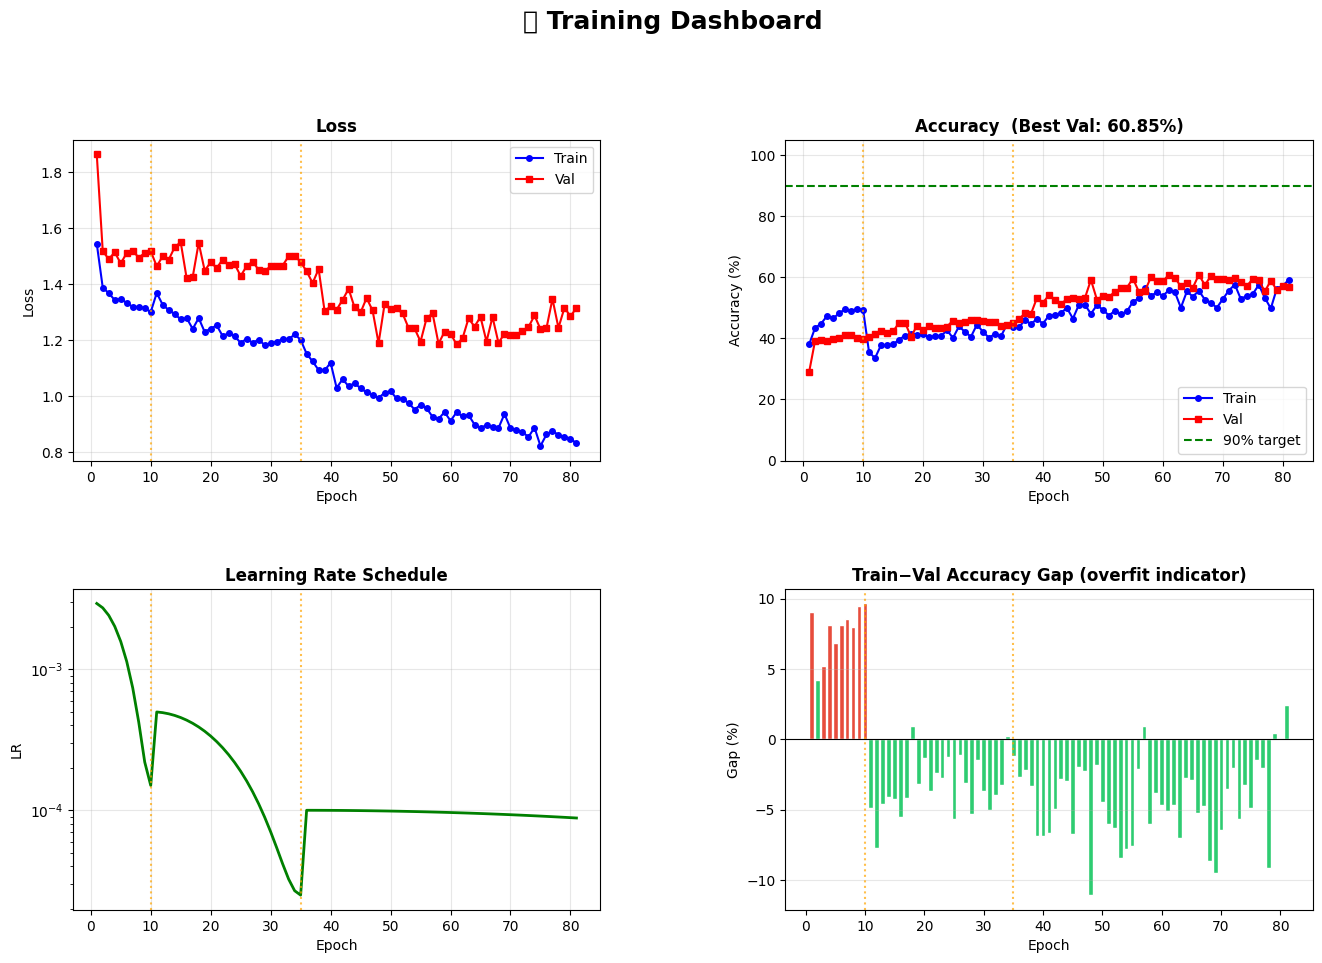


📊 Final Classification Report (TTA):
              precision    recall  f1-score   support

       anger     0.7357    0.5219    0.6106      1253
        fear     0.7713    0.5626    0.6507      1253
       happy     0.7879    0.8540    0.8196      1253
     neutral     0.5394    0.8851    0.6703      1253
         sad     0.6803    0.5690    0.6197      1253

    accuracy                         0.6785      6265
   macro avg     0.7029    0.6785    0.6742      6265
weighted avg     0.7029    0.6785    0.6742      6265



In [15]:
# ── Full training curve summary ───────────────────────────────
plot_training_progress(history, phase_boundaries[:-1])

print('\n📊 Final Classification Report (TTA):')
print(classification_report(tta_labels, tta_preds,
                             target_names=cfg.CLASSES, digits=4))

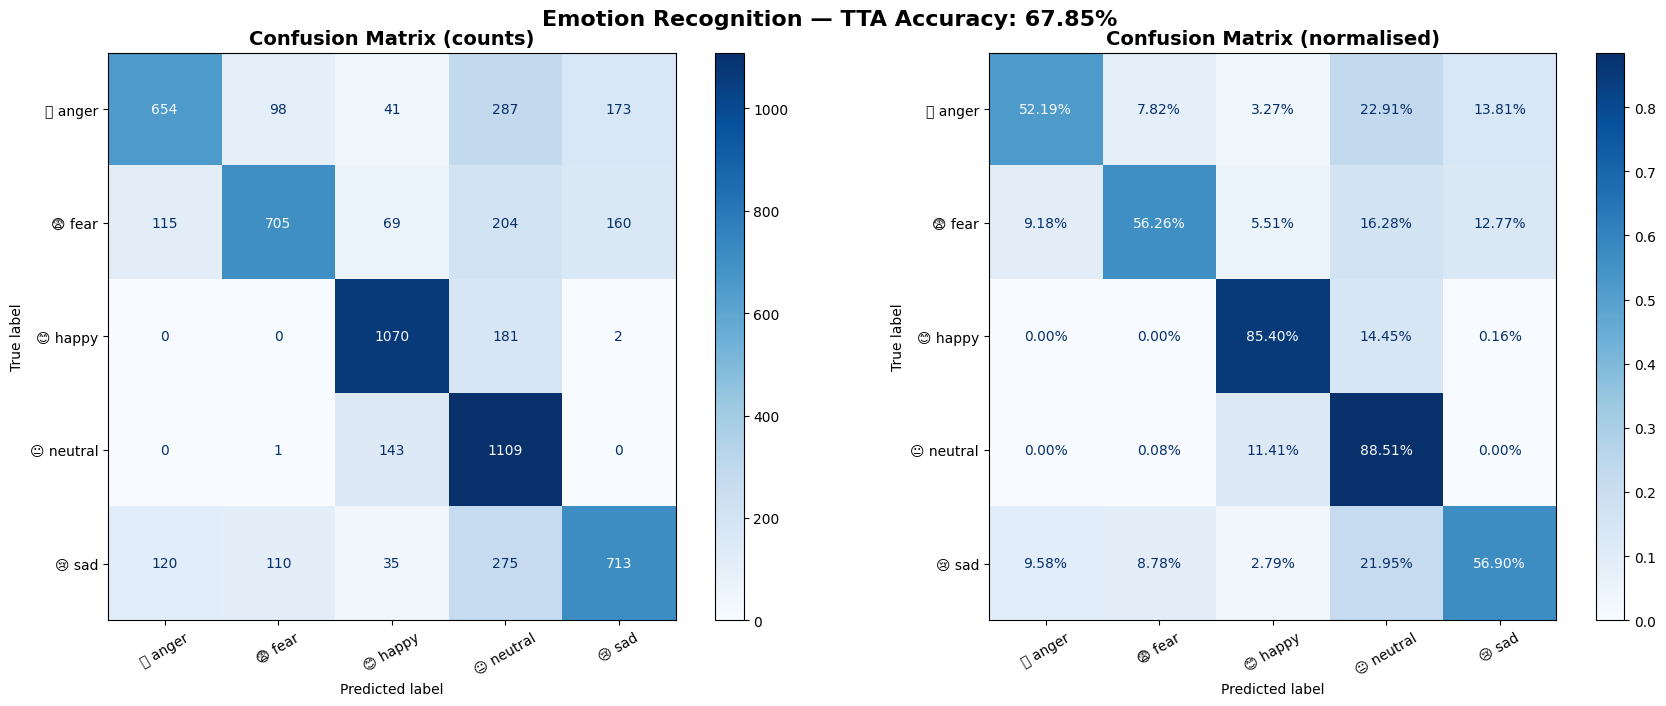

In [16]:
# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(tta_labels, tta_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2%'],
        ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)']):
    disp = ConfusionMatrixDisplay(confusion_matrix=data,
                                  display_labels=[f"{emoji.get(c,'')} {c}" for c in cfg.CLASSES])
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format=fmt)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'Emotion Recognition — TTA Accuracy: {tta_acc*100:.2f}%',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

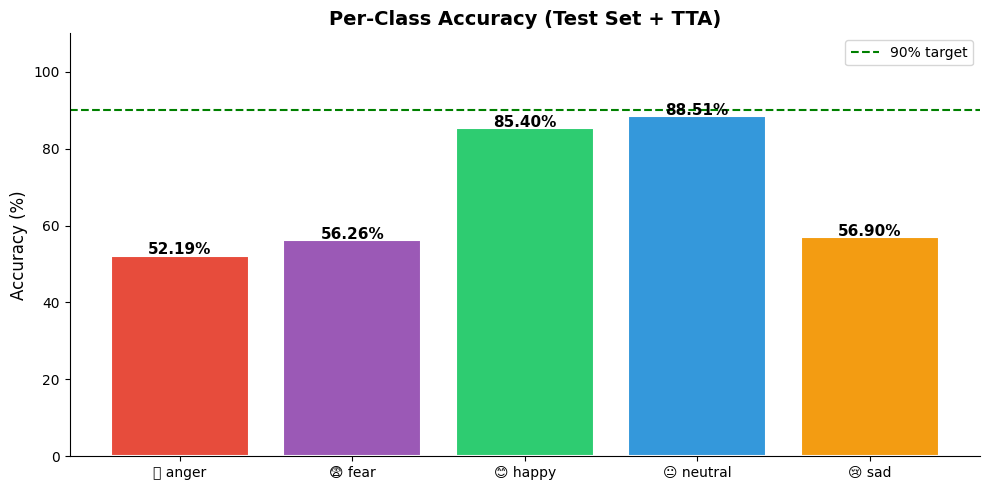

In [17]:
# ── Per-class Accuracy Bar ────────────────────────────────────
per_class_acc = cm_norm.diagonal()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([f"{emoji.get(c,'')} {c}" for c in cfg.CLASSES],
              per_class_acc * 100, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val*100:.2f}%', ha='center', fontweight='bold', fontsize=11)

ax.axhline(90, color='green', linestyle='--', linewidth=1.5, label='90% target')
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy (Test Set + TTA)', fontsize=14, fontweight='bold')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

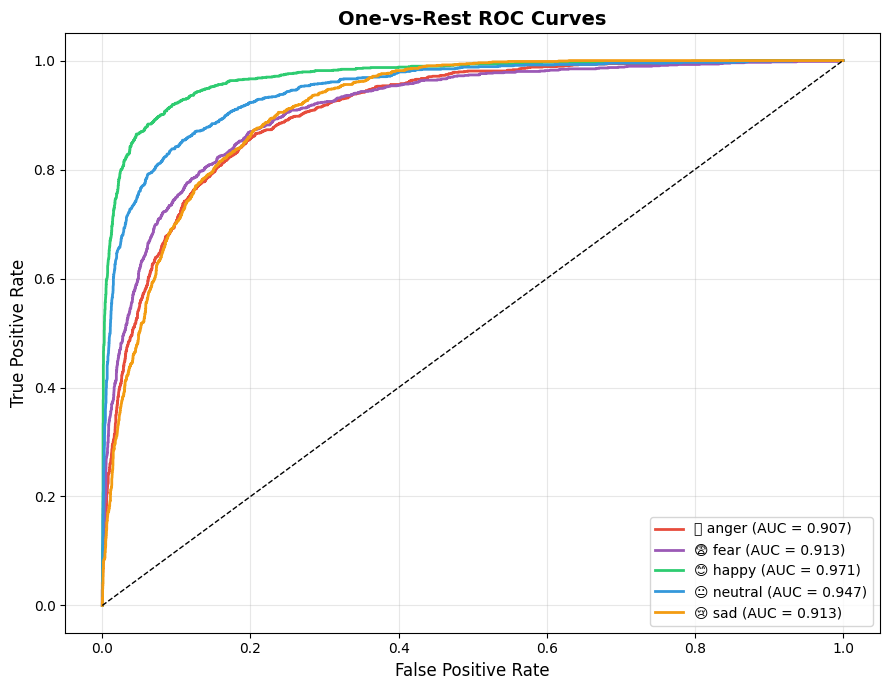

In [18]:
# ── One-vs-Rest ROC Curves ────────────────────────────────────
y_bin = label_binarize(tta_labels, classes=list(range(cfg.NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(9, 7))
for i, (cls, col) in enumerate(zip(cfg.CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], tta_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, linewidth=2,
            label=f'{emoji.get(cls,"")} {cls} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('One-vs-Rest ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

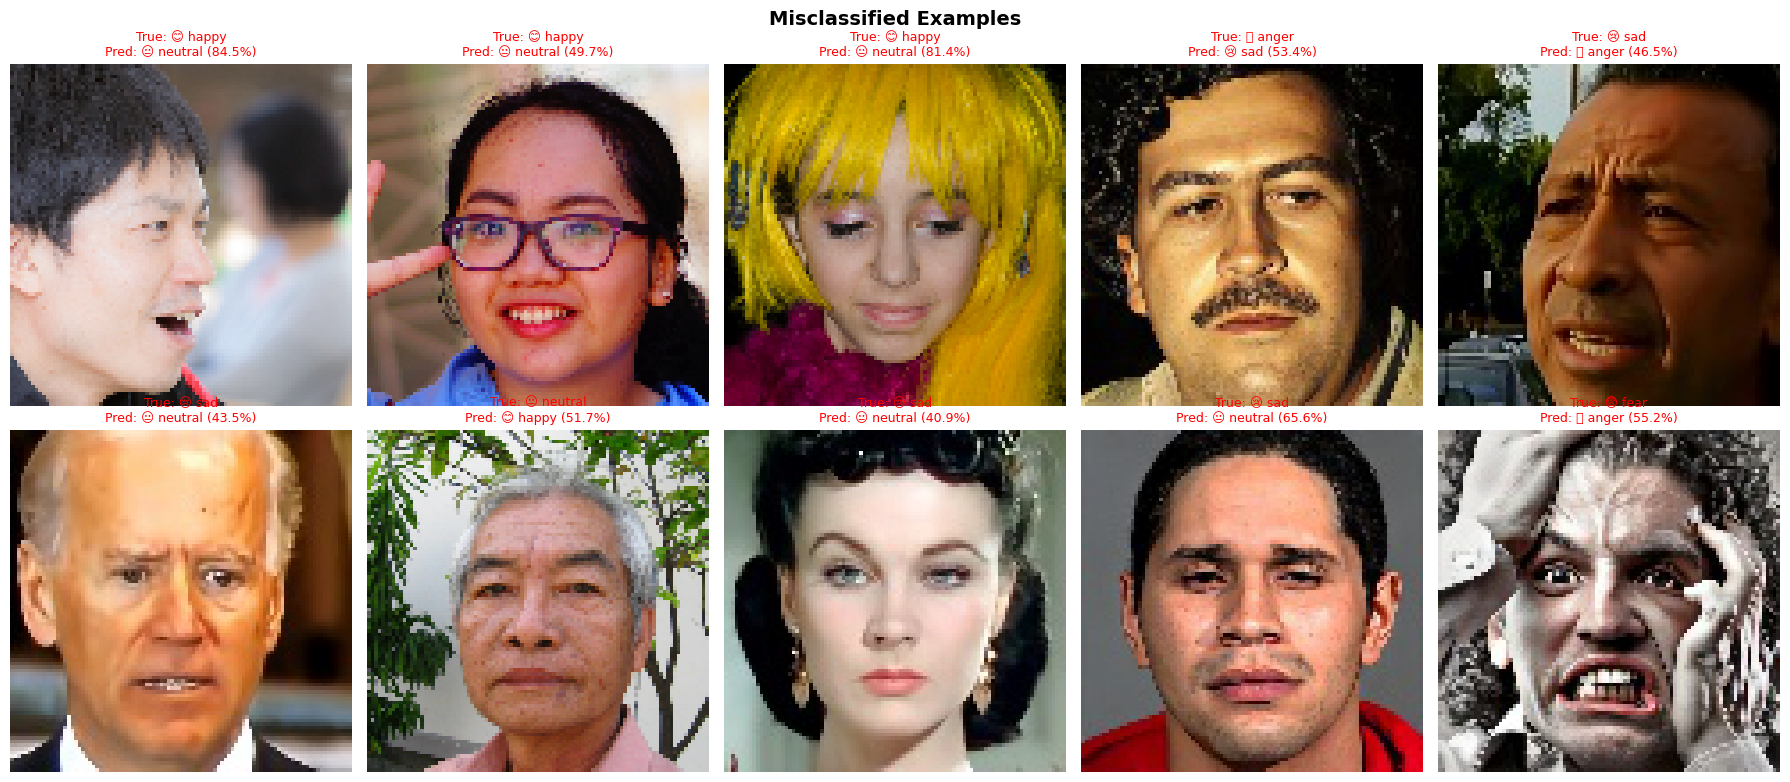

In [19]:
# ── Wrong predictions gallery ────────────────────────────────
idx2class = {v: k for k, v in train_dataset.class_to_idx.items()}

test_ds_plain = ImageFolder(cfg.TEST_DIR, transform=val_transforms)
wrong_indices = np.where(tta_preds != tta_labels)[0]
sample_wrong  = np.random.choice(wrong_indices, size=min(10, len(wrong_indices)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, idx in zip(axes.flat, sample_wrong):
    img_t, true_lbl = test_ds_plain[idx]
    img_show = unnorm(img_t).permute(1,2,0).numpy().clip(0,1)
    pred_lbl = tta_preds[idx]
    conf = tta_probs[idx][pred_lbl] * 100
    ax.imshow(img_show)
    ax.set_title(
        f'True: {emoji.get(idx2class[true_lbl],"")} {idx2class[true_lbl]}\n'
        f'Pred: {emoji.get(idx2class[pred_lbl],"")} {idx2class[pred_lbl]} ({conf:.1f}%)',
        fontsize=9, color='red')
    ax.axis('off')

plt.suptitle('Misclassified Examples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Inference on Single Image

Demo image: E:\LamMinhTri\Tai_Lieu_Hoc_Tap\2026_Semester 1\DAT301m\The_Emotion_Explorers\Mood-and-Attention-Monitoring-in-Online-Classrooms\dataset\test\neutral\ffhq_956.png  (ground truth: neutral)


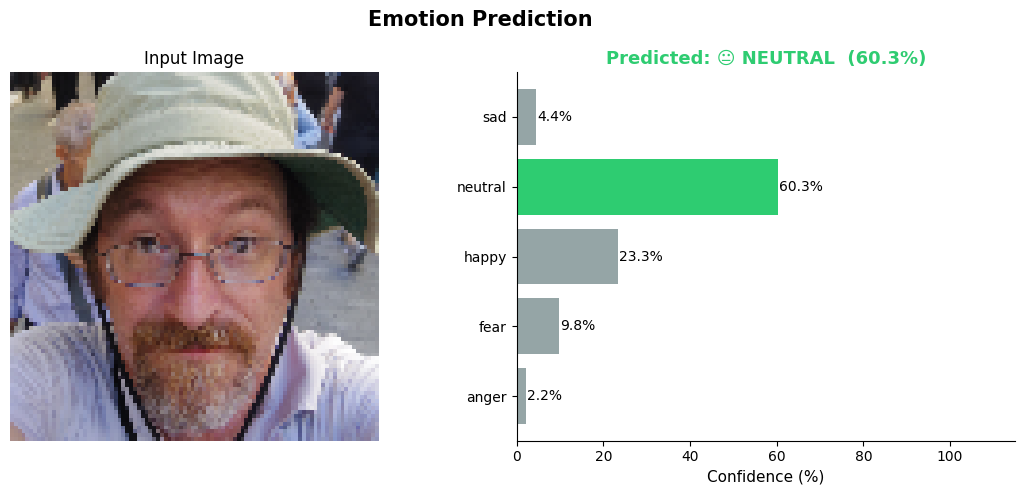

('neutral',
 array([0.02159, 0.0978 , 0.2333 , 0.6035 , 0.04388], dtype=float16))

In [20]:
@torch.no_grad()
def predict_single(image_path, model, transforms_list=tta_transforms):
    """Predict emotion for a single image with TTA."""
    img = Image.open(image_path).convert('RGB')
    model.eval()
    all_probs = []

    for tfm in transforms_list:
        t = tfm(img).unsqueeze(0).to(DEVICE)
        with autocast(enabled=cfg.USE_AMP and DEVICE.type == 'cuda'):
            out = model(t)
        all_probs.append(F.softmax(out, dim=1).cpu().numpy()[0])

    avg_probs = np.mean(all_probs, axis=0)
    pred_idx  = avg_probs.argmax()
    pred_cls  = cfg.CLASSES[pred_idx]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    axes[0].imshow(img)
    axes[0].set_title(f'Input Image', fontsize=12)
    axes[0].axis('off')

    bars = axes[1].barh(cfg.CLASSES, avg_probs * 100,
                        color=['#2ECC71' if c == pred_cls else '#95A5A6' for c in cfg.CLASSES])
    for bar, p in zip(bars, avg_probs):
        axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{p*100:.1f}%', va='center', fontsize=10)
    axes[1].set_xlim(0, 115)
    axes[1].set_xlabel('Confidence (%)', fontsize=11)
    axes[1].set_title(f'Predicted: {emoji.get(pred_cls,"")} {pred_cls.upper()}  ({avg_probs[pred_idx]*100:.1f}%)',
                      fontsize=13, fontweight='bold', color='#2ECC71')
    axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle('Emotion Prediction', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return pred_cls, avg_probs


# --- Example usage ---
# pred_class, probs = predict_single('./your_image.jpg', model)

# Demo: run on a random test image
random_cls = random.choice(cfg.CLASSES)
random_dir = os.path.join(cfg.TEST_DIR, random_cls)
random_img = os.path.join(random_dir, random.choice(os.listdir(random_dir)))
print(f'Demo image: {random_img}  (ground truth: {random_cls})')
predict_single(random_img, model)

---
## 12. Export Model

In [21]:
# # Save final model for deployment
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'classes': cfg.CLASSES,
#     'img_size': cfg.IMG_SIZE,
#     'val_accuracy': best_val_acc,
#     'tta_accuracy': tta_acc,
#     'architecture': cfg.MODEL_NAME,
# }, './checkpoints/emotion_model_final.pth')

# print(f'✅ Model exported to ./checkpoints/emotion_model_final.pth')
# print(f'\n🏆 Final Results:')
# print(f'   Best Val Accuracy  : {best_val_acc*100:.2f}%')
# print(f'   TTA Test Accuracy  : {tta_acc*100:.2f}%')
# print(f'   Target (>90%)      : {"✅ ACHIEVED" if tta_acc >= 0.90 else "❌ not yet reached"}')